# Multilabel Data Exploration

Retain overlapping recognized defects instead of forcing every image into one class.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[1]
LABELS_FILE = PROJECT_ROOT / "data" / "raw" / "archive" / "classification" / "labels.csv"
LABEL_COLUMNS = ["Surface_Crack", "Delamination", "Pinhole"]

labels_df = pd.read_csv(LABELS_FILE)
print("Original rows:", len(labels_df))
labels_df.head()

Original rows: 2227


,original_file_name,file_name,Surface_Crack,Delamination,Pinhole,unclassified
0,R7-700um-middle_frame_489_patch_1.png,image_1.jpg,1,0,0,0
1,R1-1100um-top-to-bottom-center-1_frame_220_pat...,image_2.jpg,1,0,0,0
2,R1-1100um-top-to-bottom-center_frame_85_patch_...,image_3.jpg,1,0,1,0
3,R1-1100um-top-to-bottom-center-1_frame_190_pat...,image_4.jpg,0,0,1,0
4,R1-1100um-top-to-bottom-center_frame_218_patch...,image_5.jpg,1,0,0,0


In [2]:
labels_df["recognized_label_count"] = labels_df[LABEL_COLUMNS].sum(axis=1)

usable_df = labels_df[
    (labels_df["unclassified"] == 0)
    & (labels_df["recognized_label_count"] > 0)
].copy()

print("Usable rows:", len(usable_df))
print()
print("Number of recognized labels per image:")
print(usable_df["recognized_label_count"].value_counts().sort_index())
print()
print("Positive examples per label:")
print(usable_df[LABEL_COLUMNS].sum())

Usable rows: 2105

Number of recognized labels per image:
recognized_label_count
1    1620
2     454
3      31
Name: count, dtype: int64

Positive examples per label:
Surface_Crack    1915
Delamination      203
Pinhole           503
dtype: int64


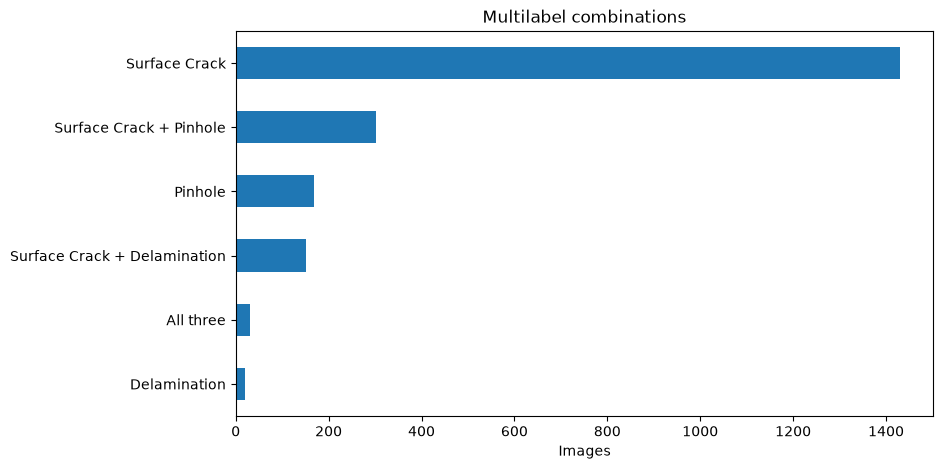

In [3]:
usable_df["label_combination"] = (
    usable_df[LABEL_COLUMNS].astype(str).agg("".join, axis=1)
)

combination_names = {
    "100": "Surface Crack",
    "010": "Delamination",
    "001": "Pinhole",
    "110": "Surface Crack + Delamination",
    "101": "Surface Crack + Pinhole",
    "011": "Delamination + Pinhole",
    "111": "All three",
}

combination_counts = usable_df["label_combination"].value_counts()
combination_counts.index = [combination_names.get(x, x) for x in combination_counts.index]
combination_counts.sort_values().plot(kind="barh", figsize=(9, 5))
plt.xlabel("Images")
plt.title("Multilabel combinations")
plt.show()

## Decision

The project predicts three independent labels. `unclassified` is excluded because it is not a specific defect type. `BCEWithLogitsLoss` is used because several outputs may be positive simultaneously.